# **Análisis Exploratorio de Datos**

##  *Sobre el dataset*

El archivo **`btc_1d_data_2018_to_2025.csv`** contiene **datos históricos diarios de Bitcoin**, incluyendo:

-  **Fecha de apertura** (*Open time*)  
-  **Precio de apertura, máximo, mínimo y cierre** (*Open, High, Low, Close*)  
-  **Volumen negociado** y **número de transacciones**  
-  **Información de compradores agresivos** (*Taker buy volume*)  


👉 Para este análisis, se utilizarán exclusivamente las columnas:  

- **Date**  
- **Close**  

Esto en línea con la restricción metodológica de trabajar únicamente con el **histórico de precios de cierre**.


# **Carga y limpieza de datos**

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np 

In [5]:
btc_raw = pd.read_csv("../data/btc_1d_data_2018_to_2025.csv")
btc_raw

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,2.118299e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2589,2025-02-02,100635.66,101456.60,99747.59,99796.00,3149.622330,2025-02-02 23:59:59.999,3.167280e+08,558753,1223.084700,1.231618e+08,0
2590,2025-02-03,97700.59,97782.79,91231.00,94495.21,20992.955720,2025-02-03 23:59:59.999,1.983835e+09,2309956,9239.171560,8.738586e+08,0
2591,2025-02-04,101328.51,101660.94,100743.33,101367.77,1910.355420,2025-02-04 23:59:59.999,1.933988e+08,208849,822.417140,8.326802e+07,0
2592,2025-02-05,97763.14,98930.44,97131.43,97589.30,8160.567950,2025-02-05 23:59:59.999,7.990502e+08,1597813,3672.410530,3.596230e+08,0


## *Selección de Variables*

En la primera fase del análisis exploratorio se depura el dataset **btc_raw**, conservando únicamente las columnas:

-  **Date** (antes *Open time*, convertida a `datetime`)  
-  **Close** (convertida a `float`)  

Esto asegura: 

-  **Relevancia temporal**: facilita operaciones cronológicas, *resampling* y generación de *lags*.  
-  **Consistencia numérica**: garantiza precisión en cálculos de retornos, medias móviles y volatilidad.  
-  **Reducción de dimensionalidad**: elimina variables irrelevantes, simplificando el DataFrame y mejorando la eficiencia.  

 Con esta limpieza inicial se establece una base **sólida, precisa y lista** para el análisis financiero posterior.

In [6]:
# Nos quedamos únicamente con la fecha de apertura y el precio de cierre
btc = btc_raw[['Open time', 'Close']].copy()

# Renombramos la columna de fecha para mayor claridad
btc.rename(columns={'Open time': 'Date'}, inplace=True)

# Convertimos la fecha a tipo datetime
btc['Date'] = pd.to_datetime(btc['Date'])

# Aseguramos que el precio de cierre sea tipo float
btc['Close'] = btc['Close'].astype(float)

# Cálculo del retorno logarítmico diario
btc['LogReturn'] = np.log(btc['Close'] / btc['Close'].shift(1))


btc.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2594 entries, 0 to 2593
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2594 non-null   datetime64[ns]
 1   Close      2594 non-null   float64       
 2   LogReturn  2593 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 60.9 KB


## *Revisión de valores faltantes* 

In [7]:
# Conteo de valores nulos por columna
btc.isnull().sum()


Date         0
Close        0
LogReturn    1
dtype: int64

Se realizó un conteo de valores nulos por columna para garantizar la integridad del dataset antes de las transformaciones estadísticas. El resultado confirmó que no existen valores faltantes en **Date** ni en **Close**, lo que permite avanzar con confianza al cálculo de retornos, volatilidad y generación de *features*.  

# **Estadística descriptiva**

## *Precio de cierre*

In [8]:
btc_close_summary = pd.DataFrame({
    'Estadística': [
        'Media',
        'Mediana',
        'Desviación estándar',
        'Mínimo',
        'Máximo',
        'Rango',
        'Cuartil 25%',
        'Cuartil 50%',
        'Cuartil 75%'
    ],
    'Valor': [
        btc['Close'].mean(),
        btc['Close'].median(),
        btc['Close'].std(),
        btc['Close'].min(),
        btc['Close'].max(),
        btc['Close'].max() - btc['Close'].min(),
        btc['Close'].quantile(0.25),
        btc['Close'].quantile(0.50),
        btc['Close'].quantile(0.75)
    ]
})

styled_table = (
    btc_close_summary.style
    .format({'Valor': '{:,.2f}'})
    .background_gradient(subset=['Valor'], cmap='Purples')
    .set_properties(**{'text-align': 'left'})
)

styled_table



,Estadística,Valor
0,Media,"29,090.19"
1,Mediana,"22,741.11"
2,Desviación estándar,"23,576.23"
3,Mínimo,"3,211.72"
4,Máximo,"106,143.82"
5,Rango,"102,932.10"
6,Cuartil 25%,"9,068.84"
7,Cuartil 50%,"22,741.11"
8,Cuartil 75%,"43,527.39"


In [9]:
btc_date_range = pd.DataFrame({
    'Estadística': ['Rango temporal'],
    'Valor': [f"{btc['Date'].min().date()} → {btc['Date'].max().date()}"]
})

# Mostrar ambas tablas
btc_close_summary.style.format({'Valor': '{:,.2f}'}).background_gradient(subset=['Valor'], cmap='Purples')
btc_date_range

,Estadística,Valor
0,Rango temporal,2018-01-01 → 2025-02-06


Se analizaron los precios de cierre de **BTC** entre el **1 de enero de 2018** y el **6 de febrero de 2025**, con un total de **2,594 observaciones diarias**. El análisis revela que el precio presenta una **media de $29,090** y una **mediana de $22,741**, lo que sugiere una distribución asimétrica positiva. La **desviación estándar de $23,576** evidencia una fuerte dispersión y confirma la alta volatilidad del activo.  

El rango alcanza los **$102,932**, con valores mínimos de **$3,211** y máximos de **$106,143**, lo que refleja la magnitud de los ciclos de mercado. Además, el **50% de los precios** se concentra entre **$9,068 y $43,527**, mostrando una marcada variabilidad en niveles intermedios con colas largas.  



## *Retornos logarítmicos* 

In [10]:
btc_logret_summary = pd.DataFrame({
    'Estadística': [
        'Media',
        'Mediana',
        'Desviación estándar',
        'Mínimo',
        'Máximo',
        'Rango',
        'Cuartil 25%',
        'Cuartil 50%',
        'Cuartil 75%',
        'Retorno acumulado',
        'Rendimiento total (%)'
    ],
    'Valor': [
        btc['LogReturn'].mean(),
        btc['LogReturn'].median(),
        btc['LogReturn'].std(),
        btc['LogReturn'].min(),
        btc['LogReturn'].max(),
        btc['LogReturn'].max() - btc['LogReturn'].min(),
        btc['LogReturn'].quantile(0.25),
        btc['LogReturn'].quantile(0.50),
        btc['LogReturn'].quantile(0.75),
        btc['LogReturn'].sum(),
        (np.exp(btc['LogReturn'].sum()) - 1) * 100  # rendimiento total en %
    ]
})

# Aplicar estilo visual con paleta Purples
styled_logret_table = (
    btc_logret_summary.style
    .format({'Valor': '{:,.6f}'})
    .background_gradient(subset=['Valor'], cmap='Purples')
    .set_properties(**{'text-align': 'left'})
)

styled_logret_table

,Estadística,Valor
0,Media,0.000769
1,Mediana,0.000708
2,Desviación estándar,0.036221
3,Mínimo,-0.502607
4,Máximo,0.178449
5,Rango,0.681056
6,Cuartil 25%,-0.014171
7,Cuartil 50%,0.000708
8,Cuartil 75%,0.016304
9,Retorno acumulado,1.994559


El análisis de los **retornos logarítmicos diarios de BTC** muestra una dinámica marcada por **alta volatilidad**, **colas pesadas** y **asimetría**.

La **media (0.00077)** y la **mediana (0.00071)** son positivas pero cercanas a cero, lo que indica ligeros rendimientos diarios en promedio, con cierta simetría central. Sin embargo, la **desviación estándar (0.0362)** confirma una fuerte dispersión: el retorno mínimo (−50%) evidencia caídas abruptas, mientras que el máximo (≈18%) señala alzas notables pero menos extremas, lo que revela una **asimetría negativa**.  

En términos de dispersión intermedia, el **50% de los retornos diarios** se ubica entre −1.4% y +1.6%, mostrando movimientos moderados en la mayoría de los días, aunque los **extremos frecuentes** refuerzan la existencia de colas pesadas.  

El **retorno acumulado** es significativo: la suma de log-retornos (≈1.995) equivale a un rendimiento total de **≈634.8%** en el periodo, lo que valida a BTC como un activo de alto crecimiento, aunque acompañado de alto riesgo.


## *Evolución anual del precio y retornos del BTC*

In [11]:
# Extraemos el año como nueva columna
btc['Year'] = btc['Date'].dt.year

# Agrupamos por año y calculamos estadísticas
annual_stats = btc.groupby('Year').agg({
    'Close': ['mean', 'std', 'min', 'max'],
    'LogReturn': ['mean', 'std']
})

# Visualización ordenada
annual_stats.columns = ['Close_mean', 'Close_std', 'Close_min', 'Close_max', 'LogReturn_mean', 'LogReturn_std']
annual_stats = annual_stats.round(4)
annual_stats


,Close_mean,Close_std,Close_min,Close_max,LogReturn_mean,LogReturn_std
Year,,,,,,
2018,7538.1139,2404.4230,3211.72,17069.79,-0.0035,0.0440
2019,7364.3632,2646.5728,3398.40,13093.80,0.0018,0.0357
2020,11110.5485,4309.4733,4800.00,28923.63,0.0038,0.0424
2021,47400.0030,9770.9924,29331.69,67525.83,0.0013,0.0424
2022,28185.2179,10188.5129,15781.29,47722.65,-0.0028,0.0337
2023,28849.5918,5901.6370,16616.75,44170.99,0.0026,0.0228
2024,65963.5927,14679.3342,39568.02,106133.74,0.0022,0.0276
2025,99803.1170,3807.7701,92552.49,106143.82,0.0013,0.0276


Esta tabla resume la dinámica anual del precio de cierre de BTC y sus retornos logarítmicos, permitiendo identificar **cambios estructurales**, **ciclos de volatilidad** y **tendencias de crecimiento**.  


### 🔹 2018–2019 
- **Precio promedio**: alrededor de $7,500  
- **Retorno medio**: negativo en 2018 (−0.0035), positivo en 2019 (0.0018)  
- **Volatilidad**: alta en ambos años, con desviaciones estándar > 0.035  
- **Interpretación**: BTC inicia en fase bajista tras el pico de 2017; 2018 refleja corrección prolongada, mientras que 2019 muestra recuperación. La dispersión elevada confirma un mercado inestable.  


### 🔹 2020–2021 
- **Precio promedio**: $11,110 en 2020 y se cuadruplica en 2021  
- **Retorno medio**: positivo y creciente (0.0038 en 2020)  
- **Volatilidad**: elevada (~0.042)  
- **Interpretación**: en 2020, los estímulos monetarios e interés institucional impulsan el precio. 2021 marca un ciclo especulativo con máximos históricos; los retornos se moderan pero la volatilidad persiste.  


### 🔹 2022 
- **Precio promedio**: cae a $28,185  
- **Retorno medio**: negativo (−0.0028)  
- **Volatilidad**: ligeramente menor  
- **Interpretación**: tras el rally de 2021, el mercado entra en fase de corrección. Los precios y retornos caen, pero la volatilidad aún es significativa.  


### 🔹 2023–2025  
- **Precio promedio**: estable en 2023 (~$28,850), con fuerte alza en 2024 y 2025  
- **Retorno medio**: positivo pero más moderado  
- **Volatilidad**: en descenso (0.0228 en 2023, 0.0276 en 2025)  
- **Interpretación**: BTC muestra maduración; precios alcanzan nuevos máximos, retornos diarios son más estables y la volatilidad disminuye, posiblemente por mayor liquidez y participación institucional.  

In [12]:
# Asegurar que las columnas sean planas (sin MultiIndex)
annual_stats.columns = annual_stats.columns.to_flat_index()
annual_stats.columns = [
    'Precio promedio (USD)',
    'Desviación estándar del precio',
    'Precio mínimo',
    'Precio máximo',
    'Retorno logarítmico promedio',
    'Desviación estándar del retorno'
]


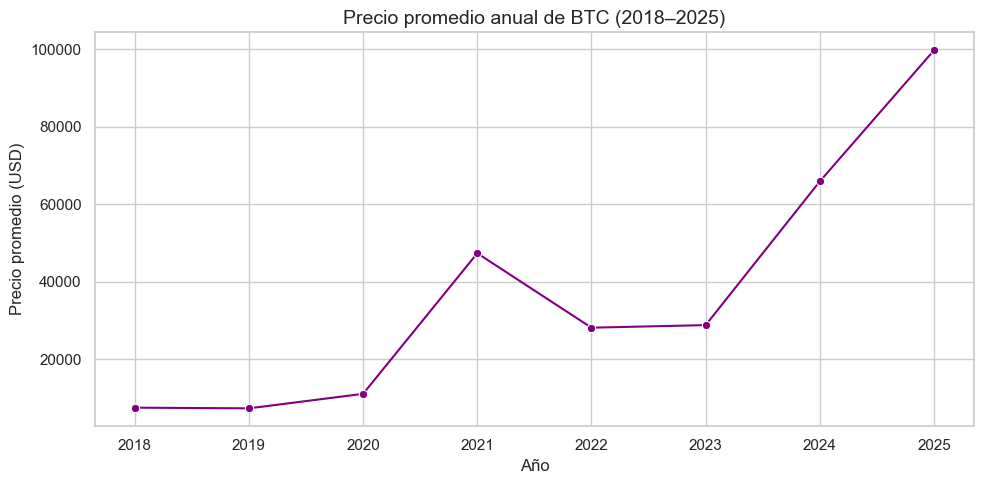

In [13]:
sns.set(style='whitegrid', palette='Purples')

# Gráfico de líneas del precio promedio anual
plt.figure(figsize=(10, 5))
sns.lineplot(data=annual_stats, x=annual_stats.index, y='Precio promedio (USD)', marker='o', color='purple')
plt.title('Precio promedio anual de BTC (2018–2025)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Precio promedio (USD)')
plt.xticks(annual_stats.index)
plt.tight_layout()
plt.show()

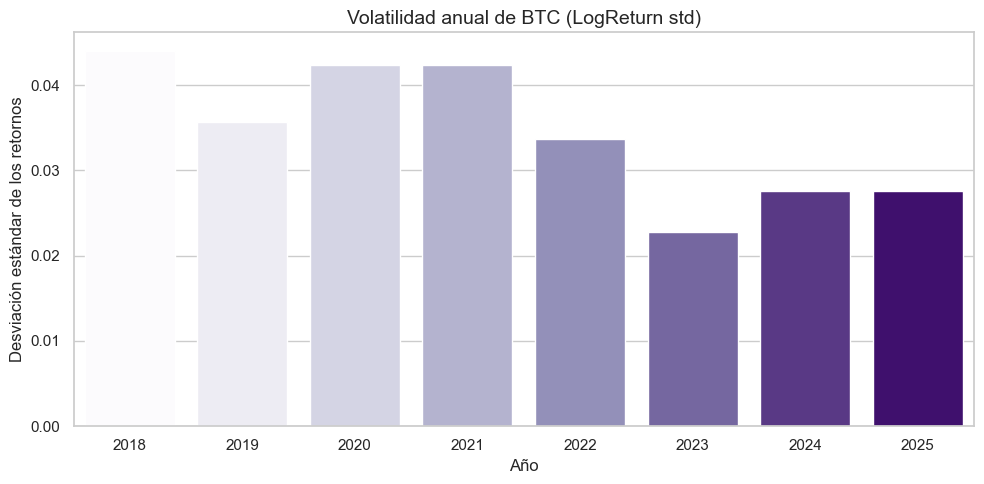

In [14]:
# Gráfico de barras de la volatilidad anual
plt.figure(figsize=(10, 5))
sns.barplot(x=annual_stats.index, y='Desviación estándar del retorno', data=annual_stats, palette='Purples', hue=annual_stats.index, legend= False)
plt.title('Volatilidad anual de BTC (LogReturn std)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Desviación estándar de los retornos')
plt.tight_layout()
plt.show() 


- **Evolución del precio promedio:**  
  El primer gráfico revela cómo el **precio promedio anual** ha evolucionado, con saltos destacados en **2021, 2024 y 2025**, lo que refleja los principales ciclos alcistas de BTC.  

- **Volatilidad del mercado:**  
  El segundo gráfico muestra cómo la **volatilidad ha disminuido progresivamente desde 2021**, lo que sugiere una **posible maduración del mercado** con retornos más estables.  

# **Visualizaciones**

## *Serie temporal del precio de cierre*

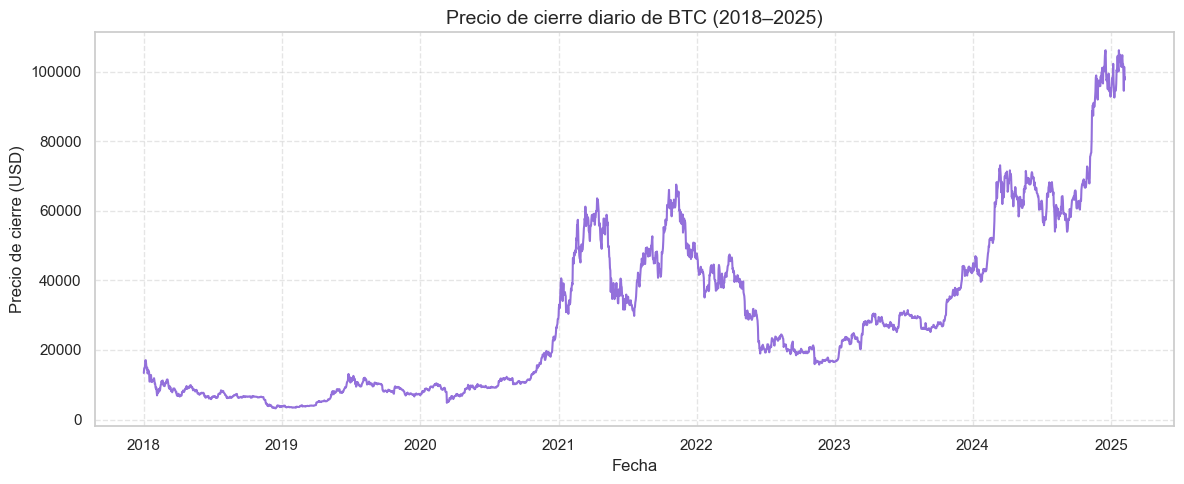

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(btc['Date'], btc['Close'], color='#9370DB')  
plt.title("Precio de cierre diario de BTC (2018–2025)", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### Tendencias generales de BTC

- **2018–2020**: Periodo de relativa estabilidad con precios entre **$3,000 y $10,000 USD**.
- **2021**: Aumento abrupto con máximos de **$60,000–$65,000 USD**.
- **2022–2023**: Etapa de **fuerte corrección**, con caídas pronunciadas. 
- **2024–2025**: Nuevo **ciclo alcista**, con precios que superan los **$100,000 USD**.

###  Volatilidad de BTC

- El gráfico evidencia una alta volatilidad estructural, con movimientos bruscos tanto al alza como a la baja.
- Los picos y valles son frecuentes, lo que refuerza la necesidad de modelar no solo el precio, sino también su volatilidad como variable objetivo.

Para fines de modelado, esto implica la necesidad de incluir lags temporales, modelos multisalida y técnicas capaces de capturar dependencias no lineales, así como considerar mecanismos de regularización y detección de cambios estructurales. 


## *Serie de retornos*

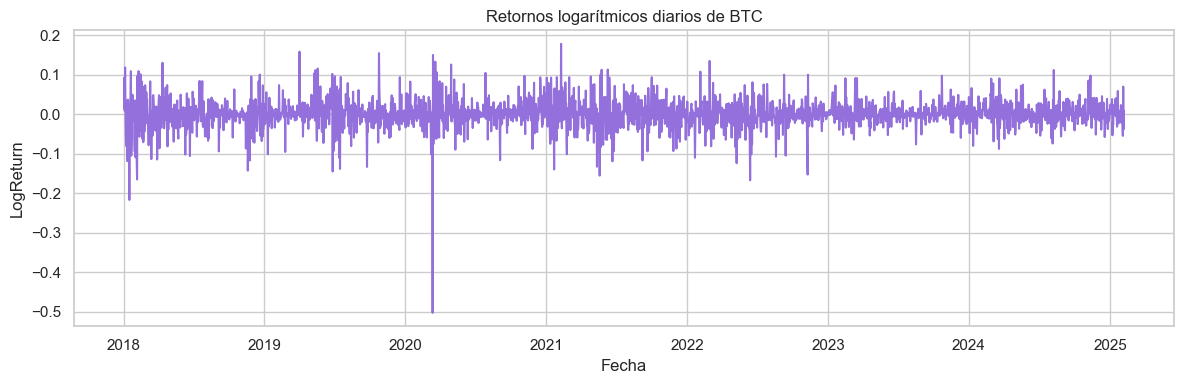

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(btc['Date'], btc['LogReturn'], color='#9370DB')
plt.title("Retornos logarítmicos diarios de BTC")
plt.xlabel("Fecha")
plt.ylabel("LogReturn")
plt.grid(True)
plt.tight_layout()
plt.show()


### *Comportamiento de los retornos*

- La serie de retornos oscila alrededor de **cero**, como es habitual en activos financieros.  
- Se aprecian **picos abruptos** positivos y negativos que reflejan movimientos extremos en el precio.  
- Un evento destacado ocurre en **2020**, el cual más adelante veremos especialmente junto a otros picos extremos.

### *Volatilidad agrupada*

- Aunque los retornos parecen aleatorios, se distinguen periodos de **alta intensidad** seguidos de fases más tranquilas.  
- Este comportamiento confirma la **heterocedasticidad**, es decir, la varianza no es constante en el tiempo. Se verá con más detalle a continuación.  
- Ello justifica el uso de métricas como **rolling std** o modelos de volatilidad como **GARCH**.  



### *Posibles explicaciones de los picos abruptos*

- Picos negativos


In [17]:
btc.sort_values(by='LogReturn').head(5)


,Date,Close,LogReturn,Year
801,2020-03-12,4800.00,-0.502607,2020
15,2018-01-16,10900.00,-0.216880,2018
1624,2022-06-13,22487.41,-0.166998,2022
35,2018-02-05,6939.99,-0.164980,2018
1234,2021-05-19,36690.09,-0.155194,2021


| Fecha       | Retorno logarítmico | Caída aprox. | Contexto                                                                 | Impacto                                                                                     |
|-------------|---------------------|--------------|--------------------------------------------------------------------------|---------------------------------------------------------------------------------------------|
| 2020-03-12  | −0.5026             | −39.6%       | *“Jueves negro”* del COVID-19: venta masiva global de activos de riesgo.  | Inicio del bull market 2020-21. BTC pasó de desplome a activo **antifrágil** frente al QE.   |
| 2018-01-16  | −0.2169             | −19.5%       | *“Crypto Carnage”* por rumores de regulaciones en Corea del Sur.          | Señal clara del **cambio de ciclo**. Inicio del bear market con pérdidas >80% posteriores.   |
| 2022-06-13  | −0.1670             | −15.4%       | Bloqueo de retiros en Celsius y contagio tras colapso de Terra/Luna.      | Aceleración del bear market 2022. Quiebras de CeFi y auge de **autocustodia/DeFi**.         |
| 2018-02-05  | −0.1650             | −15.2%       | Segunda ola de corrección de 2018 con presión regulatoria en Asia.        | Confirmó la **tendencia bajista**. Golpe psicológico que consolidó el fin del rally 2017.   |
| 2021-05-19  | −0.1552             | −14.4%       | China refuerza restricciones y prohíbe servicios financieros con cripto.  | **Éxodo del hashrate** hacia Occidente. Red más descentralizada y resiliente a mediano plazo.|


- Picos positivos

In [18]:
btc.sort_values(by='LogReturn', ascending=False).head(5)


,Date,Close,LogReturn,Year
1134,2021-02-08,46374.87,0.178449,2021
456,2019-04-02,4857.29,0.158684,2019
662,2019-10-25,8655.02,0.154984,2019
802,2020-03-13,5578.60,0.150322,2020
1519,2022-02-28,43160.00,0.135279,2022


| Fecha       | Retorno logarítmico | Subida aprox. | Contexto                                                                | Impacto                                                                                   |
|-------------|---------------------|---------------|-------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| 2021-02-08  | +0.1784             | +19.5%        | Tesla anuncia compra de $1.5B en BTC y que aceptará pagos en cripto.    | Nuevo máximo histórico >$46k. Punto de inflexión para la **adopción institucional**.      |
| 2019-04-02  | +0.1587             | +17.2%        | Ruptura técnica de resistencia en $4,200 con activación de órdenes.     | Rally inmediato a $4,800. Señal del fin del **bear market 2018**.                         |
| 2019-10-25  | +0.1550             | +16.7%        | Xi Jinping promueve el blockchain como tecnología estratégica en China. | Interpretado como respaldo indirecto a BTC. Subida a ~$10,300 en un solo día.             |
| 2020-03-13  | +0.1503             | +16.2%        | Rebote técnico tras el *crash* del COVID-19 del 12 de marzo.            | Recuperación parcial: de ~$3,800 a ~$5,500. Inicio de una recuperación sostenida.         |
| 2022-02-28  | +0.1353             | +14.5%        | Estalla la guerra en Ucrania. Kiev recibe donaciones en BTC y ETH.      | BTC usado como activo refugio. Crece el trading en rublos y hryvnias.                     |


## *Histograma de retornos*

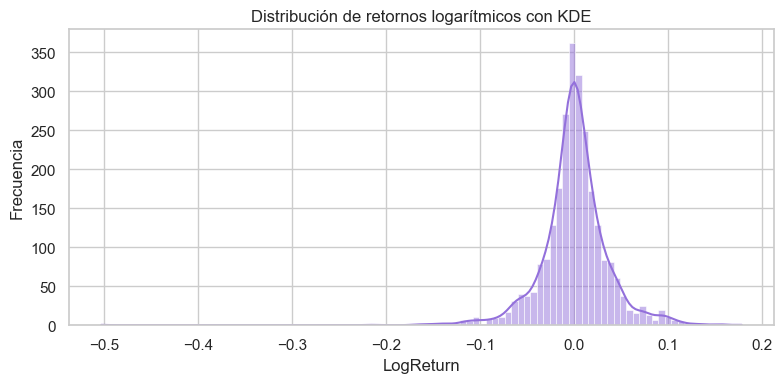

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(btc['LogReturn'], bins=100, kde=True, color='#9370DB')
plt.title("Distribución de retornos logarítmicos con KDE")
plt.xlabel("LogReturn")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()


El gráfico muestra que la mayoría de los retornos diarios de Bitcoin se concentran cerca de cero, reflejando movimientos pequeños en la mayor parte del tiempo. Sin embargo, presenta una asimetría negativa, ya que las caídas tienden a ser más intensas que las subidas, con una cola izquierda más larga que evidencia episodios de pérdidas abruptas como los del 12 de marzo de 2020 o el 16 de enero de 2018. Este comportamiento es característico de activos financieros altamente volátiles, cuya distribución se centra en cero pero presenta colas pesadas, lo que sugiere un riesgo significativo de movimientos extremos.

Para corroborar estas observaciones, se calcularán medidas estadísticas de forma, como la **asimetría** y la **curtosis**, que permiten cuantificar el sesgo hacia caídas más extremas y la presencia de colas pesadas en la distribución de los retornos.



In [20]:
logret = btc['LogReturn'].dropna() 

In [21]:
from scipy.stats import skew, kurtosis

print("Asimetría (Skewness):", skew(logret))
print("Curtosis:", kurtosis(logret))


Asimetría (Skewness): -1.1575570438518914
Curtosis: 17.01619756942232


El análisis de forma de la distribución de los retornos muestra una **asimetría (skewness) de −1.16**, lo que confirma una cola más larga hacia la izquierda: las caídas abruptas son más frecuentes o intensas que las subidas equivalentes. Asimismo, la **curtosis de 17.02** (muy superior al valor de 3 en una normal) revela colas pesadas y una alta probabilidad de eventos extremos. Estos resultados corroboran que la distribución de BTC no es normal en sentido estadístico, lo que justifica el uso de **modelos robustos para volatilidad** y métricas de evaluación no dependientes de supuestos de normalidad (MAE, MAPE, percentiles).


## *ACF de LogReturn*

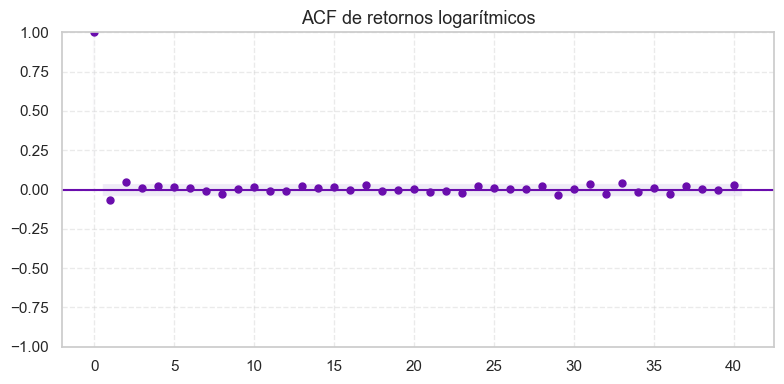

In [22]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Crear figura y eje
fig, ax = plt.subplots(figsize=(8, 4))

# Graficar ACF con estilo morado
plot_acf(logret, lags=40, ax=ax)

# Personalizar color de los puntos y líneas
for line in ax.lines:
    line.set_color('#6a0dad')  # tono púrpura

for patch in ax.patches:
    patch.set_facecolor('#6a0dad')
    patch.set_alpha(0.6)

# Personalizar bandas de confianza (sombreado)
for polygon in ax.collections:
    polygon.set_facecolor('#b19cd9')  # púrpura claro
    polygon.set_alpha(0.2)

# Título y estilo
ax.set_title("ACF de retornos logarítmicos", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



La autocorrelación en lag 0 es naturalmente alta (valor 1), ya que representa la correlación de la serie consigo misma. Para lags mayores a 0, los valores están muy cerca de cero, lo que indica que los retornos logarítmicos diarios de BTC son prácticamente independientes en el tiempo, sugiriendo un comportamiento cercano al ruido blanco y respaldando la hipótesis de eficiencia del mercado. Para cuantificar estadísticamente esta independencia, se aplicará la **prueba de Ljung-Box**, la cual evalúa si existe autocorrelación significativa en los lags seleccionados, permitiendo determinar de manera objetiva si los retornos diarios se comportan como ruido blanco. 


In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Test de Ljung-Box para los retornos
ljung_ret = acorr_ljungbox(logret, lags=[10], return_df=True)
print("Ljung-Box para LogReturn:\n", ljung_ret)


Ljung-Box para LogReturn:
       lb_stat  lb_pvalue
10  23.785027   0.008192


Para los retornos logarítmicos diarios de BTC, el p-valor de la prueba de Ljung-Box es 0.008, lo que indica una dependencia leve pero significativa hasta el lag 10. Aunque la ACF mostraba visualmente poca autocorrelación, este resultado sugiere la existencia de patrones sutiles que no son evidentes a simple vista. Esto enfatiza la necesidad de un análisis más profundo si se busca modelar cualquier dependencia temporal en los retornos.


## *ACF de LogReturn²*

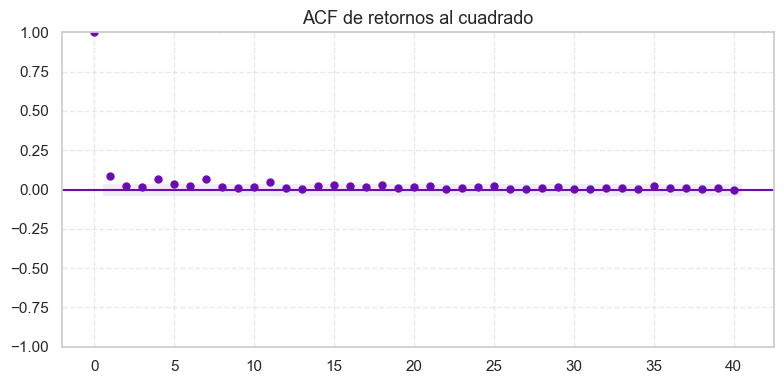

In [24]:
# Crear figura y eje
fig, ax = plt.subplots(figsize=(8, 4))

# Graficar ACF de retornos al cuadrado
plot_acf(logret**2, lags=40, ax=ax)

# Personalizar color de líneas y barras
for line in ax.lines:
    line.set_color('#6a0dad')  # púrpura intenso

for patch in ax.patches:
    patch.set_facecolor('#6a0dad')
    patch.set_alpha(0.6)

# Personalizar sombreado de bandas de confianza
for polygon in ax.collections:
    polygon.set_facecolor('#b19cd9')  # púrpura claro
    polygon.set_alpha(0.2)

# Título y estilo
ax.set_title("ACF de retornos al cuadrado", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



La autocorrelación de los retornos al cuadrado muestra que, aunque la mayoría de los lags se encuentran dentro del intervalo de confianza, existe una persistencia leve en los primeros lags. Esto indica que la volatilidad tiende a agruparse en el tiempo, un fenómeno conocido como *volatility clustering*, típico en activos financieros: días con alta volatilidad suelen ser seguidos por otros días también volátiles. Para cuantificar formalmente esta dependencia temporal, se aplicará la prueba de **Ljung-Box**, que permitirá evaluar si la autocorrelación observada es estadísticamente significativa.



In [25]:
# Test de Ljung-Box para los retornos al cuadrado
ljung_ret2 = acorr_ljungbox(logret**2, lags=[10], return_df=True)
print("Ljung-Box para LogReturn²:\n", ljung_ret2)


Ljung-Box para LogReturn²:
      lb_stat     lb_pvalue
10  50.45701  2.199140e-07


Para los retornos al cuadrado, el p-valor del test de Ljung-Box es 2.2e−07, lo que indica una dependencia temporal altamente significativa en la varianza. Esto confirma la presencia de *volatility clustering*, donde días volátiles tienden a estar seguidos por otros días igualmente volátiles.


# **Preprocesamiento financiero**

## *Cálculo de retornos logarítmicos*

In [26]:
# Cálculo de LogReturn
btc['LogReturn'] = np.log(btc['Close'] / btc['Close'].shift(1))

> ⚠️ **Nota aclaratoria**  
> Aunque el cálculo de `LogReturn` se presenta formalmente en esta sección, fue aplicado previamente para facilitar las visualizaciones y análisis exploratorios. Esta estructura busca mantener la coherencia metodológica del flujo de trabajo, sin comprometer la reproducibilidad del código.


## *Cálculo de volatilidad histórica*

In [27]:
# Volatilidad anualizada con ventana de 30 días
btc['Volatility'] = btc['LogReturn'].rolling(window=30).std() * np.sqrt(252)


>  **Volatilidad histórica anualizada (ventana de 30 días)**  
> Se calcula la volatilidad histórica como la desviación estándar móvil de los retornos logarítmicos, multiplicada por la raíz de 252 para anualizarla (asumiendo 252 días hábiles por año).  
>  
> La elección de una ventana de **30 días** responde a criterios financieros estándar: representa aproximadamente un mes de operaciones, lo que permite capturar dinámicas recientes sin ser excesivamente sensibles al ruido diario. Esta serie se utiliza como **variable objetivo alternativa** para el modelo de predicción de volatilidad, permitiendo evaluar si la red MLP logra replicar o mejorar esta estimación no paramétrica.


## *Visualización de volatilidad*

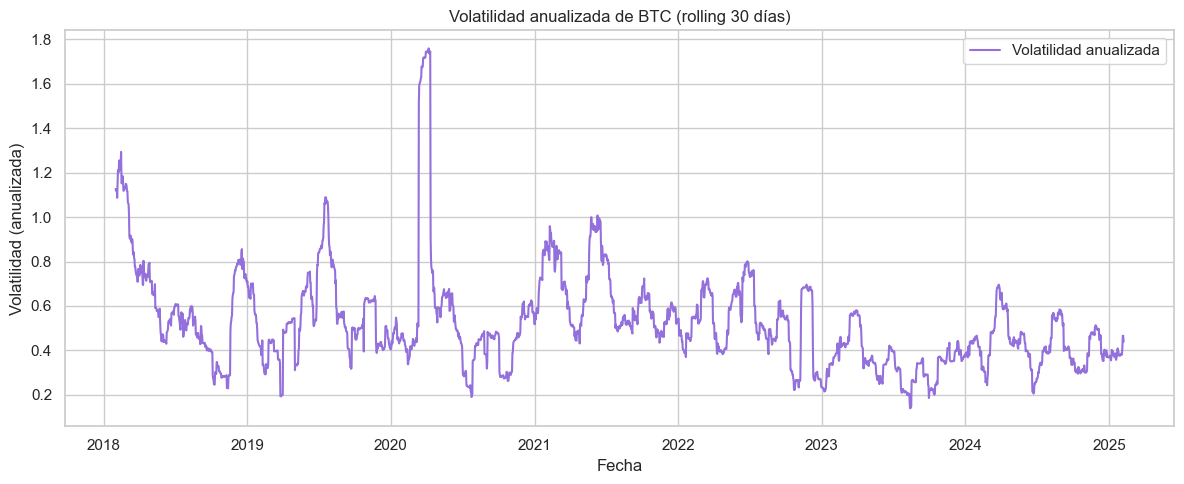

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(btc['Date'], btc['Volatility'], color='#9370DB', label='Volatilidad anualizada')
plt.title("Volatilidad anualizada de BTC (rolling 30 días)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (anualizada)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


La **volatilidad anualizada** calculada con una ventana móvil de 30 días muestra claros **patrones de agrupamiento** en la serie temporal de BTC. Se destacan episodios de alta volatilidad:

- **Marzo 2020:** Volatilidad extrema asociada al crash por COVID-19.  
- **Mayo 2021:** Alta incertidumbre por restricciones regulatorias en China.  
- **Junio 2022:** Colapso de plataformas como Celsius y Terra/Luna.  

Estos picos evidencian que la volatilidad **no es constante**, sino que **tiende a persistir en el tiempo**, validando su uso como variable objetivo en modelos de predicción. La magnitud de los picos (hasta 1.6) indica que BTC puede experimentar **variaciones diarias de hasta ±10%** en periodos de tensión elevada.

## *Precio vs Volatilidad*

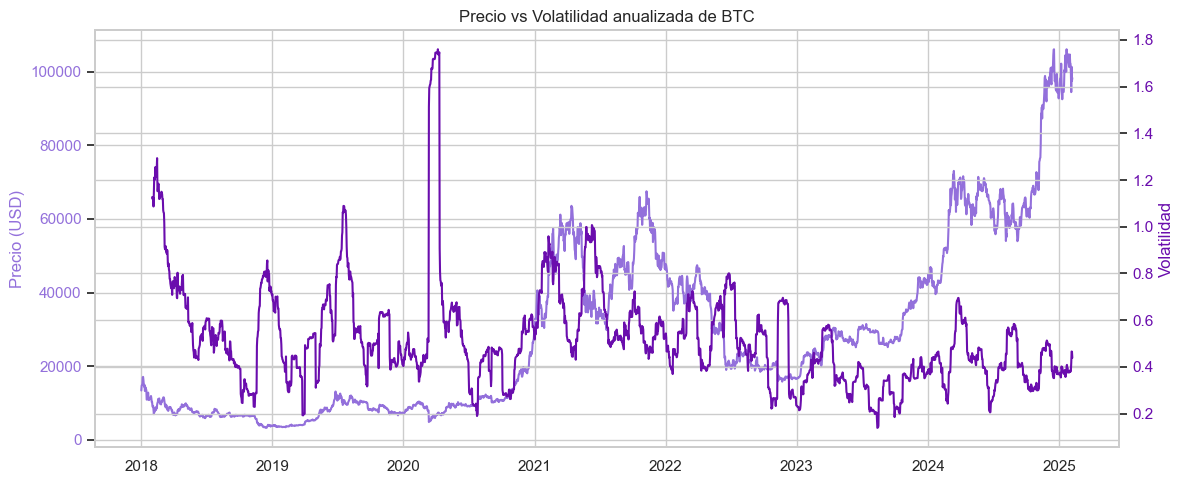

In [29]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Precio
ax1.plot(btc['Date'], btc['Close'], color='#9370DB', label='Precio BTC')
ax1.set_ylabel('Precio (USD)', color='#9370DB')
ax1.tick_params(axis='y', labelcolor='#9370DB')

# Volatilidad (eje secundario)
ax2 = ax1.twinx()
ax2.plot(btc['Date'], btc['Volatility'], color='#6a0dad', label='Volatilidad anualizada')
ax2.set_ylabel('Volatilidad', color='#6a0dad')
ax2.tick_params(axis='y', labelcolor='#6a0dad')

plt.title("Precio vs Volatilidad anualizada de BTC")
fig.tight_layout()
plt.show()


El gráfico revela que la volatilidad anualizada de BTC no sigue linealmente al precio, sino que responde a la intensidad y frecuencia de los movimientos diarios. Esta observación justifica el modelado separado de la volatilidad como variable objetivo, y refuerza la necesidad de capturar sus patrones temporales mediante técnicas de aprendizaje profundo.

## *Correlación entre retorno absoluto y volatilidad*

In [30]:
btc['AbsReturn'] = btc['LogReturn'].abs()
correlation = btc[['AbsReturn', 'Volatility']].corr().iloc[0,1]
print(f"Correlación entre retorno absoluto y volatilidad: {correlation:.4f}")


Correlación entre retorno absoluto y volatilidad: 0.3362


El **coeficiente de correlación** entre el retorno absoluto  y la **volatilidad anualizada**  es **0.3362**, lo que indica una relación positiva moderada. Esto sugiere que, en general, los días con movimientos más extremos en el precio de BTC, ya sean al alza o a la baja, tienden a coincidir con niveles más altos de volatilidad.

Aunque la correlación no es extremadamente alta, refuerza la idea de que la magnitud del retorno diario contiene información útil para anticipar el comportamiento de la volatilidad futura. Este hallazgo valida el uso de **lags de retornos** como variables explicativas en el modelo de predicción de volatilidad.


## *Estimación de volatilidad condicional con GARCH(1,1)*

In [31]:
from arch import arch_model

logret = logret*100 

# Creamos el modelo GARCH(1,1) sobre los retornos logarítmicos
model = arch_model(logret, vol='GARCH', p=1, q=1, mean='Constant', dist='normal')

# Ajustamos el modelo
garch_fit = model.fit(disp='off')

# Mostramos el resumen del modelo
print(garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:              LogReturn   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6862.27
Distribution:                  Normal   AIC:                           13732.5
Method:            Maximum Likelihood   BIC:                           13756.0
                                        No. Observations:                 2593
Date:                Sat, Sep 13 2025   Df Residuals:                     2592
Time:                        18:57:54   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1510  6.734e-02      2.242  2.499e-02 [1.897e-0

### Justificación del modelo GARCH(1,1)

Se ajusta un modelo GARCH(1,1) sobre los retornos logarítmicos diarios de BTC con fines exploratorios y comparativos. Este enfoque permite estimar la **volatilidad condicional**, es decir, la variabilidad esperada en los retornos en función de la información pasada.  
 
Aunque el modelo GARCH no forma parte del pipeline de predicción principal —que se basa exclusivamente en los precios de cierre y redes neuronales— su inclusión cumple tres objetivos estratégicos:
  
1. **Validación financiera**: confirma la presencia de heterocedasticidad condicional y la persistencia de la volatilidad, lo que respalda el diseño de un modelo MLP con memoria temporal.
2. **Benchmark estadístico**: genera una serie de volatilidad que sirve como referencia para evaluar si el modelo de deep learning logra capturar dinámicas similares o más complejas.
3. **Rigor metodológico**: demuestra conocimiento de enfoques clásicos en modelado de riesgo, fortaleciendo la narrativa técnica del proyecto.
  
Los resultados del modelo muestran una media positiva significativa en los retornos y una estructura de volatilidad altamente persistente (α + β ≈ 0.956), lo que valida el enfoque de modelado temporal y justifica el uso de ventanas móviles y retardos en el diseño del modelo MLP.


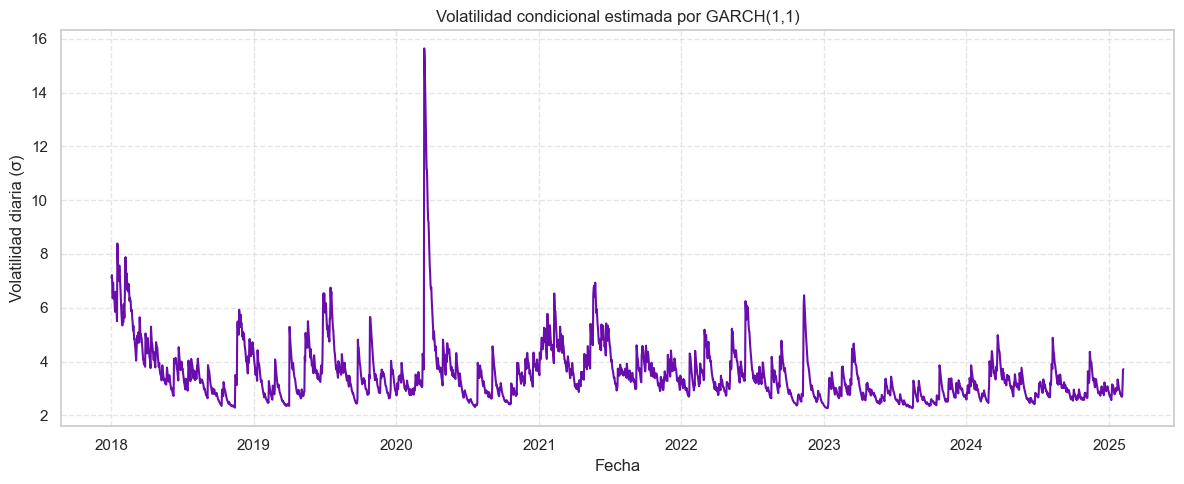

In [32]:
# Volatilidad condicional estimada (desviación estándar diaria)
btc['Volatilidad_GARCH'] = garch_fit.conditional_volatility

# Gráfico de la volatilidad estimada
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(btc['Date'], btc['Volatilidad_GARCH'], color='#6a0dad')  # tono púrpura
plt.title("Volatilidad condicional estimada por GARCH(1,1)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad diaria (σ)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


El gráfico muestra la evolución diaria de la **volatilidad condicional** estimada mediante el modelo GARCH(1,1), aplicado sobre los retornos logarítmicos de BTC.  
 
Se observan **picos pronunciados de volatilidad** en momentos de alta incertidumbre, especialmente alrededor de 2020, lo que coincide con eventos macroeconómicos globales y fuertes movimientos en el precio de BTC.  
A partir de 2021, la volatilidad muestra una **tendencia descendente y más estable**, aunque persisten fluctuaciones moderadas hasta 2025. Esta dinámica sugiere que el mercado de BTC ha madurado parcialmente, con menor sensibilidad a shocks extremos.  
  
Esta serie condicional valida la presencia de **volatilidad persistente y estructurada**, lo que justifica el uso de modelos con memoria temporal como el MLP. Además, sirve como **benchmark estadístico** para evaluar si el modelo de red neuronal logra capturar patrones similares o más complejos.


# **Generación de features**

## *a. Lags del precio*

In [33]:
# Crear lags del precio
for i in range(1, 29):
    btc[f'lag_{i}'] = btc['Close'].shift(i)


> Se generan variables de **retardo (`lag`)** del precio de cierre de BTC desde 1 hasta 28 días atrás. Estas variables permiten capturar la **dependencia temporal** del mercado, es decir, cómo el comportamiento pasado influye en la dinámica actual.  
>  
> La elección de **28 días** como límite superior responde a la estructura mensual del mercado, alineándose con la ventana usada en la volatilidad realizada (`rolling.std`) y en las medias móviles. Esto asegura coherencia metodológica y suficiente profundidad temporal sin introducir ruido excesivo.  
>  
> Estas variables enriquecen el modelo con señales de momentum, reversión y persistencia, y pueden ser combinadas con medias móviles y volatilidad para mejorar la capacidad predictiva.


### *Agrupación por ventanas*

In [34]:
# Promedios móviles por ventana
btc['mean_7'] = btc['Close'].rolling(window=7).mean()
btc['mean_14'] = btc['Close'].rolling(window=14).mean()
btc['mean_21'] = btc['Close'].rolling(window=21).mean()
btc['mean_28'] = btc['Close'].rolling(window=28).mean()


> Se calculan medias móviles de los precios de cierre de BTC con ventanas de **7, 14, 21 y 28 días**, con el objetivo de capturar tendencias de corto y mediano plazo en la dinámica del mercado.  


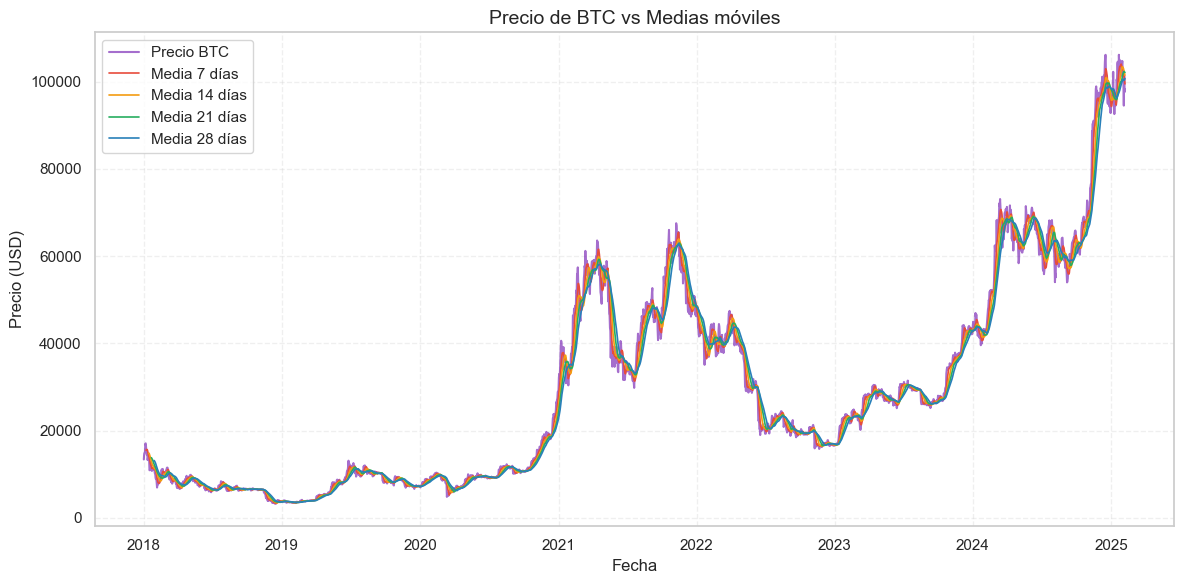

In [35]:
plt.figure(figsize=(12, 6))

# Precio original
plt.plot(btc['Date'], btc['Close'], label='Precio BTC', color='#6a0dad', linewidth=1.5, alpha=0.6)

# Medias móviles con colores diferenciados
plt.plot(btc['Date'], btc['mean_7'], label='Media 7 días', color='#e74c3c', linewidth=1.2)     # rojo
plt.plot(btc['Date'], btc['mean_14'], label='Media 14 días', color='#f39c12', linewidth=1.2)   # naranja
plt.plot(btc['Date'], btc['mean_21'], label='Media 21 días', color='#27ae60', linewidth=1.2)   # verde
plt.plot(btc['Date'], btc['mean_28'], label='Media 28 días', color='#2980b9', linewidth=1.2)   # azul

# Estética
plt.title("Precio de BTC vs Medias móviles", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



El gráfico muestra la evolución del precio diario de BTC junto a sus medias móviles de **7, 14, 21 y 28 días**, calculadas sobre el precio de cierre.  
  
Estas curvas suavizadas permiten identificar **tendencias locales y transiciones de mercado**. Se observa que:
  
 - La media de **7 días** sigue de cerca el precio, capturando microtendencias y reversiones rápidas.
 - Las medias de **14 y 21 días** actúan como filtros intermedios, suavizando el ruido sin perder sensibilidad.
 - La media de **28 días** revela la dirección mensual del mercado, útil para validar rupturas o consolidaciones.
  
En momentos de alta volatilidad, las medias móviles divergen, lo que puede indicar **cambios de régimen** o fases de transición. En fases de consolidación, tienden a converger, reflejando estabilidad relativa.  
  
Estas variables se incorporan como **features temporales** en el modelo MLP, aportando información agregada sobre la evolución reciente del precio sin depender directamente de los retornos ni la volatilidad.


### *Visualización de corrrelaciones entre lags y target*

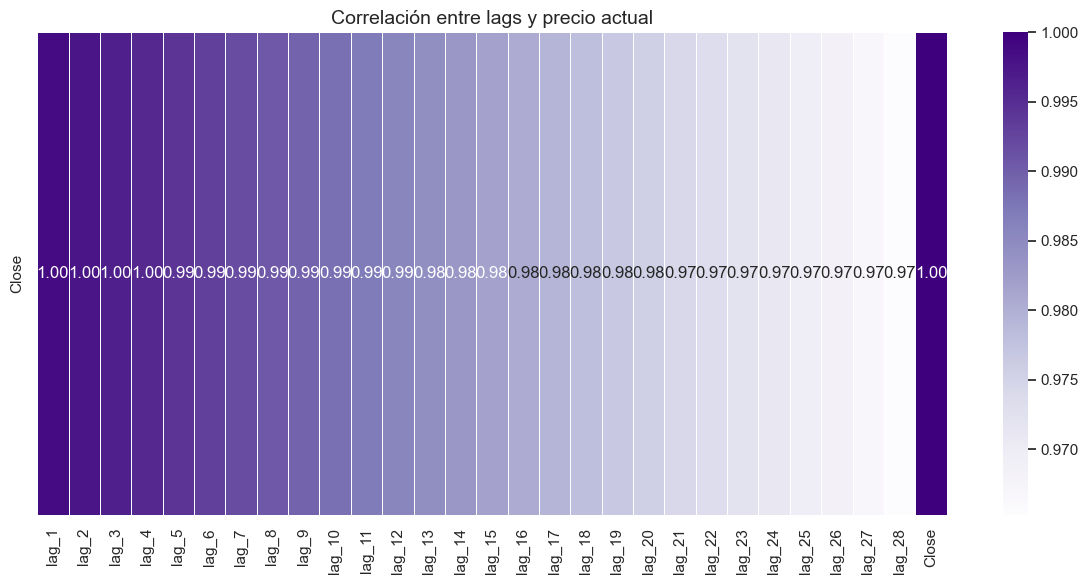

In [36]:
# Correlación entre lags y precio futuro (ejemplo: target_t+1)
corr_matrix = btc[[f'lag_{i}' for i in range(1, 29)] + ['Close']].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_matrix[['Close']].T,
    annot=True,
    cmap='Purples',      # paleta purples
    linewidths=0.5,      # separaciones entre celdas
    linecolor='white',
    fmt='.2f'
)
plt.title("Correlación entre lags y precio actual", fontsize=14)
plt.tight_layout()
plt.show()



El análisis de correlación entre los lags del precio y el valor actual (**Close**) muestra una **disminución progresiva** en la fuerza de la relación conforme aumenta el desfase temporal. Los primeros lags (lag_1 a lag_7) presentan correlaciones superiores a 0.99, lo que indica que el precio de BTC tiene una **estructura temporal fuerte a corto plazo**.

Este patrón valida el uso de **lags recientes como features predictivos**, mientras que los lags más lejanos pueden aportar ruido si no se combinan con agregaciones, como medias móviles. También sugiere que el modelo puede beneficiarse de una **arquitectura que priorice la memoria corta**, por ejemplo un MLP con atención o pesos diferenciados por lag.

Dado que el precio y la volatilidad tienen **dinámicas distintas pero interrelacionadas**, se justifica el uso de un **modelo multisalida** que prediga los objetivos:

- `target_price_t+1` a `target_price_t+7`, para capturar la dirección del mercado.  
- `target_volatility_t+1` a `target_volatility_t+7`, para anticipar el nivel de riesgo.  

Este enfoque permite construir un sistema de predicción más completo, útil tanto para decisiones de inversión como para la gestión de portafolios.


## *b. Targets multi-step*

In [37]:
# Targets multihorizonte
for i in range(1, 8):
    btc[f'target_t+{i}'] = btc['Close'].shift(-i)


> Se crean variables objetivo (`target_t+1` a `target_t+7`) que representan el **precio de cierre futuro** de BTC en horizontes de 1 a 7 días.  
>  
> Esta estrategia permite entrenar modelos supervisados que anticipen el comportamiento del mercado en distintos plazos, desde el **corto plazo (1 día)** hasta una **semana completa**, lo que es útil para distintos perfiles de decisión (trading intradía, swing trading, gestión de riesgo).  
>  
> La estructura multihorizonte también permite:
> - Evaluar la **capacidad de generalización** del modelo en distintos marcos temporales.
> - Comparar el rendimiento predictivo según el horizonte (por ejemplo, si el modelo es más preciso en t+1 que en t+7).
> - Diseñar arquitecturas que predigan múltiples salidas simultáneamente (multi-output MLP), o entrenar modelos independientes por horizonte.
>  
> Esta formulación es coherente con el enfoque temporal del proyecto, y permite una evaluación más rica del desempeño del modelo en escenarios reales de toma de decisiones.


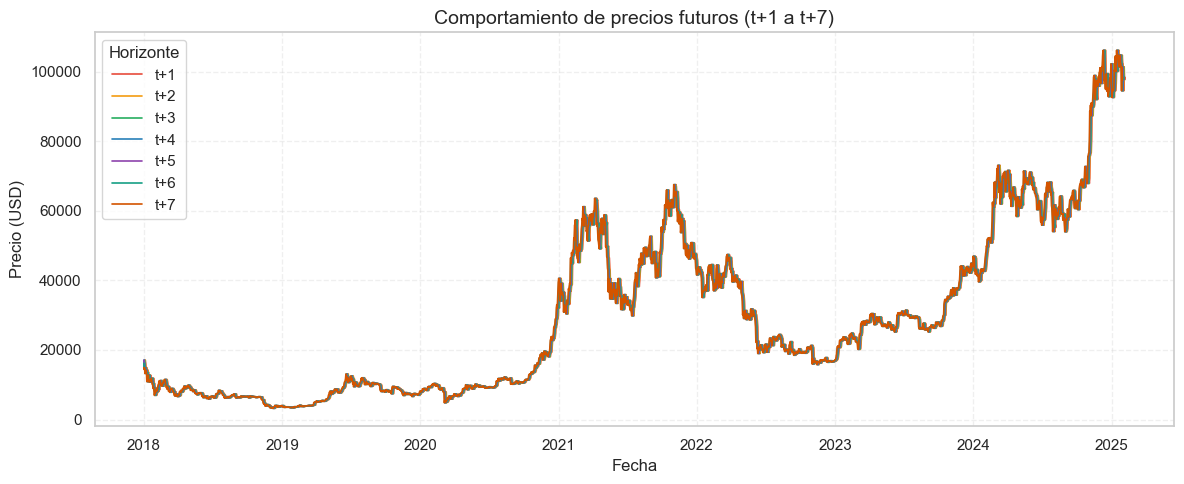

In [38]:
plt.figure(figsize=(12, 5))

# Paleta de colores diferenciados para cada horizonte
colors = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9', '#8e44ad', '#16a085', '#d35400']

# Graficar cada horizonte con su color correspondiente
for i in range(1, 8):
    plt.plot(btc['Date'], btc[f'target_t+{i}'], label=f't+{i}', color=colors[i-1], linewidth=1.2)

# Estética
plt.title("Comportamiento de precios futuros (t+1 a t+7)", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend(title="Horizonte")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



Se observa que todas las curvas siguen la estructura general del precio original, pero con **desplazamientos temporales** que reflejan la anticipación de cada horizonte.  
 
- Los horizontes más cortos (`t+1`, `t+2`) se mantienen cercanos al precio actual, capturando microvariaciones.  
- A medida que el horizonte se amplía (`t+5`, `t+7`), las curvas se suavizan y divergen ligeramente, lo que refleja mayor incertidumbre y menor precisión en la proyección.  
  
Esta visualización permite evaluar la **estabilidad temporal** del activo y anticipar cómo varía la dificultad de predicción según el plazo. También valida la necesidad de un enfoque multihorizonte, ya que cada horizonte presenta una dinámica distinta que puede requerir ajustes específicos en el modelo.


In [39]:
# Crear tabla de métricas de dispersión
dispersion_metrics = pd.DataFrame(columns=['Horizonte', 'Desviación estándar', 'Rango'])

for i in range(1, 8):
    diff = btc[f'target_t+{i}'] - btc['Close']
    dispersion_metrics.loc[i-1] = [
        f't+{i}',
        diff.std(),
        diff.max() - diff.min()
    ]

# Redondear y aplicar estilo
dispersion_metrics = dispersion_metrics.round(2)

styled_dispersion = (
    dispersion_metrics.style
    .background_gradient(subset=['Desviación estándar', 'Rango'], cmap='Purples')
    .set_properties(**{'text-align': 'left'})
)
styled_dispersion


,Horizonte,Desviación estándar,Rango
0,t+1,1171.220000,15316.680000
1,t+2,1609.860000,20642.410000
2,t+3,1961.530000,21879.620000
3,t+4,2259.980000,25032.950000
4,t+5,2539.930000,27016.780000
5,t+6,2795.750000,32407.960000
6,t+7,3021.570000,34618.220000


 La tabla muestra cómo varía la **desviación estándar** y el **rango absoluto** entre el precio actual (`Close`) y los precios futuros (`target_t+1` a `target_t+7`).  
  
 Se observa una **tendencia creciente en ambas métricas** conforme se amplía el horizonte de predicción:
  
 - En `t+1`, la desviación estándar es de **$1,171**  y el rango de  **$15,316**, lo que indica una variabilidad moderada y mayor precisión potencial.
 - En `t+7`, la desviación estándar asciende a **$3,021**  y el rango supera los  **$34,000**, reflejando una mayor dispersión e incertidumbre acumulada.
  
 Esta progresión valida que los horizontes más largos presentan **mayor dificultad predictiva**, lo que puede requerir:
 - Arquitecturas más robustas o especializadas.
 - Funciones de pérdida adaptadas a la magnitud del error.
 - Técnicas de regularización o ensembles para mejorar estabilidad.
  
 Además, esta información puede ser usada para **priorizar horizontes más estables** (`t+1` a `t+3`) en etapas iniciales del entrenamiento, o para ajustar el peso de cada horizonte en modelos multisalida.


# **Conclusiones del EDA**

##  Hallazgos clave

- El precio de cierre de BTC muestra una **distribución asimétrica positiva**, con alta dispersión (std ≈ $23,576) y un rango amplio (~$102,932), reflejando ciclos de mercado intensos.
- Los **retornos logarítmicos diarios** presentan **asimetría negativa (−1.16)** y **curtosis elevada (17.02)**, lo que confirma colas pesadas y eventos extremos. El retorno acumulado en el periodo es ≈634.8%.
- La **volatilidad anualizada** exhibe agrupamiento temporal (*volatility clustering*) y picos en momentos críticos (COVID-19, regulaciones, colapsos), con variaciones diarias de hasta ±10%.
- La **autocorrelación de retornos** es baja, pero los retornos al cuadrado muestran dependencia significativa (p ≈ 2.2e−07), lo que valida el modelado explícito de la varianza.
- El **coeficiente de correlación** entre el retorno absoluto y la volatilidad es moderado (r ≈ 0.3362), lo que sugiere que los movimientos extremos en precio tienden a coincidir con alta volatilidad.
- Las **medias móviles** de 7, 14, 21 y 28 días capturan tendencias locales y transiciones de mercado, útiles como features agregadas.
- Los **lags del precio** muestran correlaciones >0.99 en los primeros 7 días, lo que valida su uso como variables predictivas de corto plazo.
- Los **targets multihorizonte** (`t+1` a `t+7`) presentan dispersión creciente, lo que indica mayor dificultad predictiva en horizontes largos.

---

##  Variables seleccionadas para el modelo

**Features temporales:**
- Precio de cierre (`Close`)
- Medias móviles (`mean_7`, `mean_14`, `mean_21`, `mean_28`)
- Lags del precio (`lag_1` a `lag_28`)
- Retornos logarítmicos (`LogReturn`)
- Lags de retornos (`lag_LogReturn`)
- Volatilidad histórica (`Volatility`)

**Targets supervisados:**
- Precio futuro (`target_t+1` a `target_t+7`)

---

##  Posibles riesgos o sesgos detectados

- **No normalidad** en los retornos → riesgo de subestimar eventos extremos si se usan métricas inapropiadas.
- **Volatility clustering** → requiere modelado explícito de la varianza para evitar errores sistemáticos.
- **Lag-target overlap** → riesgo de dependencia artificial si no se separan adecuadamente en el dataset.
- **Sesgo temporal** → patrones específicos de ciertos años (e.g., 2020–2021) pueden no generalizar.
- **Eventos exógenos** (COVID, regulaciones, colapsos) → pueden distorsionar el aprendizaje si no se contextualizan.
- **Horizontes largos** → mayor dispersión y menor precisión, lo que exige arquitecturas más robustas y funciones de pérdida adaptadas.

---

> Este análisis establece una base sólida para el diseño del modelo MLP, con variables relevantes, estructuradas y alineadas con la dinámica temporal del mercado. Las advertencias metodológicas serán consideradas en la etapa de entrenamiento y validación para garantizar robustez y generalización.